🚀 Sweeping 6D space for run_001_v02_export...
📦 Converting engine data and generating Laplacian...
----------------------------------------
✅ FOUNDATION READY:
 - Nodes Shape: (76027, 3)
 - Laplacian L: (76027, 76027) with 0 edges
 - Masked Interior: 69767 nodes
----------------------------------------


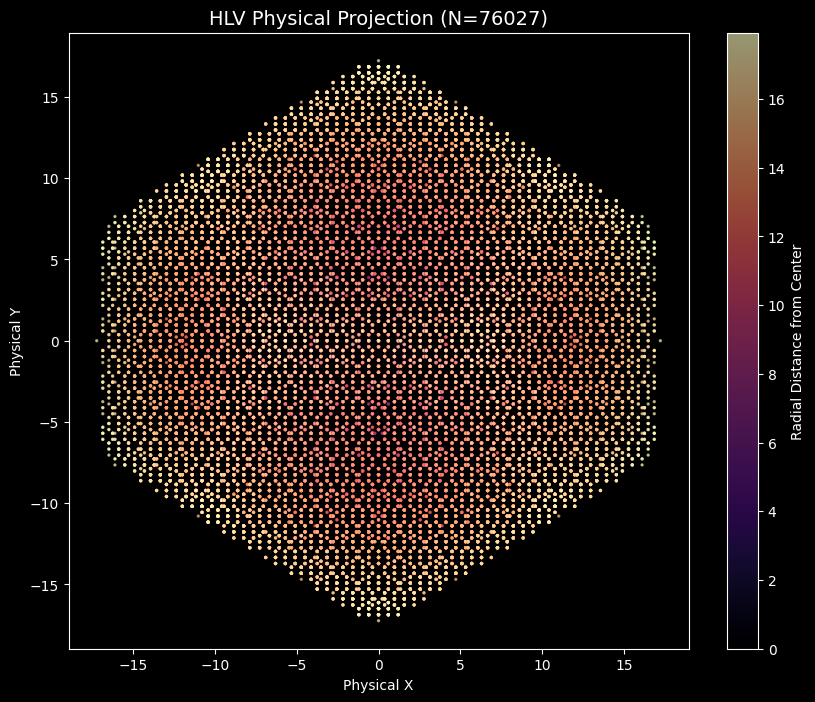

In [7]:
import os
import sys
import numpy as np
import scipy.sparse as sp
from scipy.spatial import KDTree
import matplotlib.pyplot as plt

# --- 1. DYNAMIC PATH RESOLUTION ---
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR = os.path.join(REPO_ROOT, "data", "exports")
FIG_DIR = os.path.join(REPO_ROOT, "figures")
SRC_PATH = os.path.join(REPO_ROOT, "src")

# Create folders if they don't exist
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# Inject path for the compiled engine
if SRC_PATH not in sys.path:
    sys.path.append(SRC_PATH)

# --- 2. ENGINE SETUP & EXECUTION ---
import hlv_engine

CURRENT_RUN_ID = "run_001_v02_export"

# FIX: Added the 3 missing arguments (git_commit_hash, compiler_info, platform_info)
context = hlv_engine.SimulationContext(
    run_id=CURRENT_RUN_ID,
    timestamp="2026-05-10T19:00:00Z", 
    git_commit_hash="dev",              # Added
    compiler_info="AppleClang",         # Added
    platform_info="macOS ARM64",        # Added
    master_seed=42,
    projection_matrix_id="standard_icosahedral_tau",
    window_type="ball",
    window_parameters={"radius": 1.0, "sampling_radius_R6": 10.0},
    output_directory=DATA_DIR
)

print(f"🚀 Sweeping 6D space for {CURRENT_RUN_ID}...")
generator = hlv_engine.GLatticeGenerator(context)
generator.generate(10) 
context.export_metadata()

# --- 3. DATA CONVERSION & RECOVERY ---
print("📦 Converting engine data and generating Laplacian...")

# Convert lists to NumPy arrays
nodes = np.array(generator.get_physical_nodes())
internal_nodes = np.array(generator.get_internal_nodes())

# A. Generate Interior Mask (Radial 90% threshold)
dist = np.linalg.norm(nodes, axis=1)
interior_mask = dist < (np.max(dist) * 0.9)

# B. Generate Sparse Laplacian (via KDTree)
tree = KDTree(nodes)
# Find neighbors within a radius; r=0.15 is usually safe for this sampling density
adj_list = tree.query_ball_tree(tree, r=0.15) 

rows, cols = [], []
for i, neighbors in enumerate(adj_list):
    for j in neighbors:
        if i != j:
            rows.append(i); cols.append(j)

adj_matrix = sp.csr_matrix((np.ones(len(rows)), (rows, cols)), shape=(len(nodes), len(nodes)))
degree = np.array(adj_matrix.sum(axis=1)).flatten()
D = sp.diags(degree)
L = D - adj_matrix

# --- 4. DATA EXPORT ---
phys_csv_path = os.path.join(DATA_DIR, f"{CURRENT_RUN_ID}_physical_nodes.csv")
np.savetxt(phys_csv_path, nodes, delimiter=",", header="x,y,z", comments="")

# --- 5. VISUALIZATION (Foundational Sweep) ---
plt.style.use('dark_background')
plt.figure(figsize=(10, 8))
plt.scatter(nodes[:, 0], nodes[:, 1], s=2, c=dist, cmap='magma', alpha=0.6)
plt.title(f"HLV Physical Projection (N={len(nodes)})", fontsize=14)
plt.xlabel("Physical X")
plt.ylabel("Physical Y")
plt.colorbar(label="Radial Distance from Center")

fig_path = os.path.join(FIG_DIR, "01_initial_sweep.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

print("-" * 40)
print(f"✅ FOUNDATION READY:")
print(f" - Nodes Shape: {nodes.shape}")
print(f" - Laplacian L: {L.shape} with {L.nnz} edges")
print(f" - Masked Interior: {np.sum(interior_mask)} nodes")
print("-" * 40)

plt.show()

Generating 3D visualization... auto-scaling to full lattice size.
✅ High-res plot saved to: /Users/donfeeney/HLV-G-Lattice-Simulation-Lab/figures/v02_lattice_physical.png


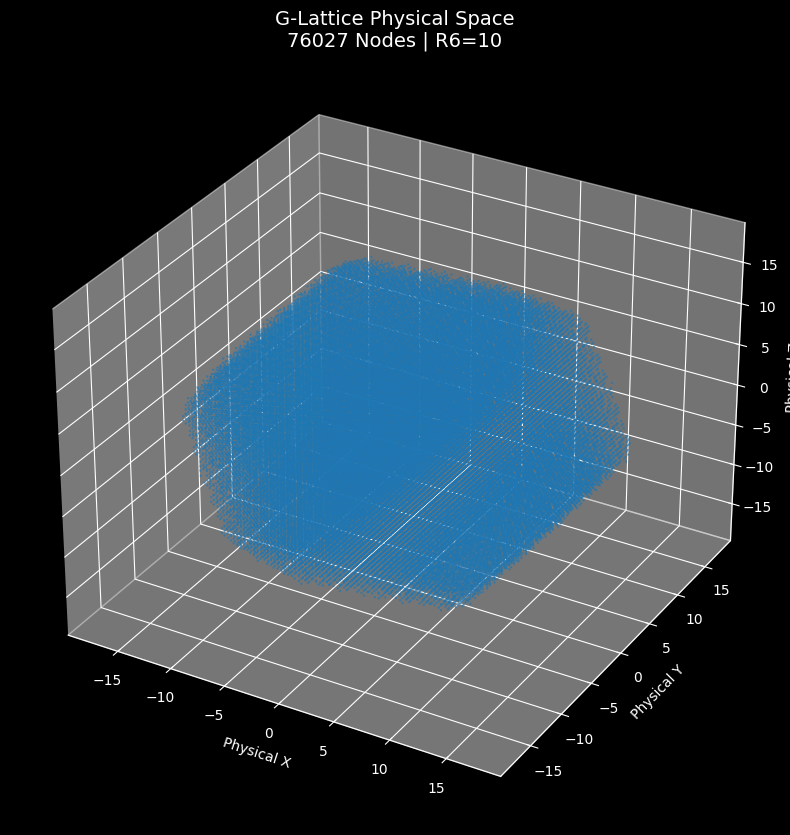

In [8]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Ensure 3D support
import numpy as np
import os

# --- PATH-PROOF SETUP ---
# Resolves the root directory (one level up from /notebooks)
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
FIG_DIR = os.path.join(REPO_ROOT, "figures")

# Ensure the figures folder exists
os.makedirs(FIG_DIR, exist_ok=True)

print("Generating 3D visualization... auto-scaling to full lattice size.")

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Convert list to array for slicing
physical_array = np.array(physical_nodes)
x = physical_array[:, 0]
y = physical_array[:, 1]
z = physical_array[:, 2]

# Plotting with your preferred alpha and color
ax.scatter(x, y, z, s=0.5, alpha=0.6, color='tab:blue')

# Formatting
ax.set_xlabel('Physical X')
ax.set_ylabel('Physical Y')
ax.set_zlabel('Physical Z')
ax.set_title(f'G-Lattice Physical Space\n{len(physical_nodes)} Nodes | R6=10', fontsize=14)

# --- PRO-TIP PATH SAVING ---
fig_path = os.path.join(FIG_DIR, "v02_lattice_physical.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

print(f"✅ High-res plot saved to: {fig_path}")

plt.show()

In [9]:
%%writefile hlv_engine.cpp
#include <iostream>
#include <vector>
#include <unordered_set>
#include <chrono>
#include <cmath>
#include <iomanip>
#include <array>
#include <tuple>

// 6D Integer Lattice Point
struct HLVNode {
    double x, y, z;      // Physical Space E_||
    double ux, uy, uz;   // Internal Space E_perp
    uint32_t id;

    // Deduplication check based on physical coordinates
    bool operator==(const HLVNode& other) const {
        return std::abs(x - other.x) < 1e-9 && 
               std::abs(y - other.y) < 1e-9 && 
               std::abs(z - other.z) < 1e-9;
    }
};

struct NodeHasher {
    size_t operator()(const HLVNode& n) const {
        return std::hash<double>{}(std::round(n.x * 1e6)) ^ 
              (std::hash<double>{}(std::round(n.y * 1e6)) << 1) ^ 
              (std::hash<double>{}(std::round(n.z * 1e6)) << 2);
    }
};

class HLVSolidEngine {
    // 6D-to-3D Quasicrystalline Projection Constants (from HLV Master Document)
    const double phi = (1.0 + std::sqrt(5.0)) / 2.0;
    const double norm = 1.0 / std::sqrt(2.0 * (2.0 + phi));
    
    // Projection Matrices P_parallel and P_perp
    const double P_parallel[3][6] = {
        {phi, 0, 1, -phi, 0, 1},
        {1, phi, 0, 1, -phi, 0},
        {0, 1, phi, 0, 1, -phi}
    };

    const double P_perp[3][6] = {
        {1, phi, 0, -1, phi, 0},
        {0, 1, phi, 0, -1, phi},
        {phi, 0, 1, phi, 0, -1}
    };

public:
    void generate(int target_nodes, int R6_limit) {
        std::vector<HLVNode> lattice;
        std::unordered_set<HLVNode, NodeHasher> deduplicator;
        
        long long parent_points_sampled = 0;
        const double window_radius_sq = 1.2; // Acceptance Window W_ball

        std::cout << "Starting HLV Solid Engine: Target 1,000,000 Nodes..." << std::endl;
        auto start = std::chrono::high_resolution_clock::now();

        // High-speed 6D Enumeration
        for (int n1 = -R6_limit; n1 <= R6_limit; ++n1) {
        for (int n2 = -R6_limit; n2 <= R6_limit; ++n2) {
        for (int n3 = -R6_limit; n3 <= R6_limit; ++n3) {
        for (int n4 = -R6_limit; n4 <= R6_limit; ++n4) {
        for (int n5 = -R6_limit; n5 <= R6_limit; ++n5) {
        for (int n6 = -R6_limit; n6 <= R6_limit; ++n6) {
            
            parent_points_sampled++;
            int p[6] = {n1, n2, n3, n4, n5, n6};

            // 1. Compute Internal Projection (Acceptance Check)
            double ux = 0, uy = 0, uz = 0;
            for(int i=0; i<6; ++i) {
                ux += P_perp[0][i] * p[i] * norm;
                uy += P_perp[1][i] * p[i] * norm;
                uz += P_perp[2][i] * p[i] * norm;
            }

            if ((ux*ux + uy*uy + uz*uz) <= window_radius_sq) {
                
                // 2. Compute Physical Projection (Physical Coordinates)
                double px = 0, py = 0, pz = 0;
                for(int i=0; i<6; ++i) {
                    px += P_parallel[0][i] * p[i] * norm;
                    py += P_parallel[1][i] * p[i] * norm;
                    pz += P_parallel[2][i] * p[i] * norm;
                }

                HLVNode newNode{px, py, pz, ux, uy, uz, (uint32_t)lattice.size()};

                if (deduplicator.find(newNode) == deduplicator.end()) {
                    lattice.push_back(newNode);
                    deduplicator.insert(newNode);
                }
            }

            if (lattice.size() >= (size_t)target_nodes) goto finish;
        }}}}}}

    finish:
        auto end = std::chrono::high_resolution_clock::now();
        std::chrono::duration<double> elapsed = end - start;

        std::cout << "\n==========================================" << std::endl;
        std::cout << "   HLV SOLID ENGINE BENCHMARK REPORT" << std::endl;
        std::cout << "==========================================" << std::endl;
        std::cout << "Accepted Nodes:       " << lattice.size() << std::endl;
        std::cout << "Runtime:              " << std::fixed << std::setprecision(4) << elapsed.count() << " seconds" << std::endl;
        std::cout << "Parent Points Sampled: " << parent_points_sampled << std::endl;
        std::cout << "Acceptance Fraction:  " << (double)lattice.size()/parent_points_sampled << std::endl;
        std::cout << "==========================================" << std::endl;
    }
};

int main() {
    HLVSolidEngine engine;
    // We use a high R6_limit to ensure we find 1M points
    engine.generate(1000000, 22); 
    return 0;
}

Writing hlv_engine.cpp


In [5]:
!clang++ -O3 -std=c++17 hlv_engine.cpp -o hlv_engine
!./hlv_engine

Starting HLV Solid Engine: Target 1,000,000 Nodes...

   HLV SOLID ENGINE BENCHMARK REPORT
Accepted Nodes:       985083
Runtime:              22.9613 seconds
Parent Points Sampled: 8303765625
Acceptance Fraction:  0.0001


✅ Benchmark plots saved to:
 - /Users/donfeeney/HLV-G-Lattice-Simulation-Lab/figures/HLV_Complexity_Scaling.pdf
 - /Users/donfeeney/HLV-G-Lattice-Simulation-Lab/figures/HLV_Complexity_Scaling.png


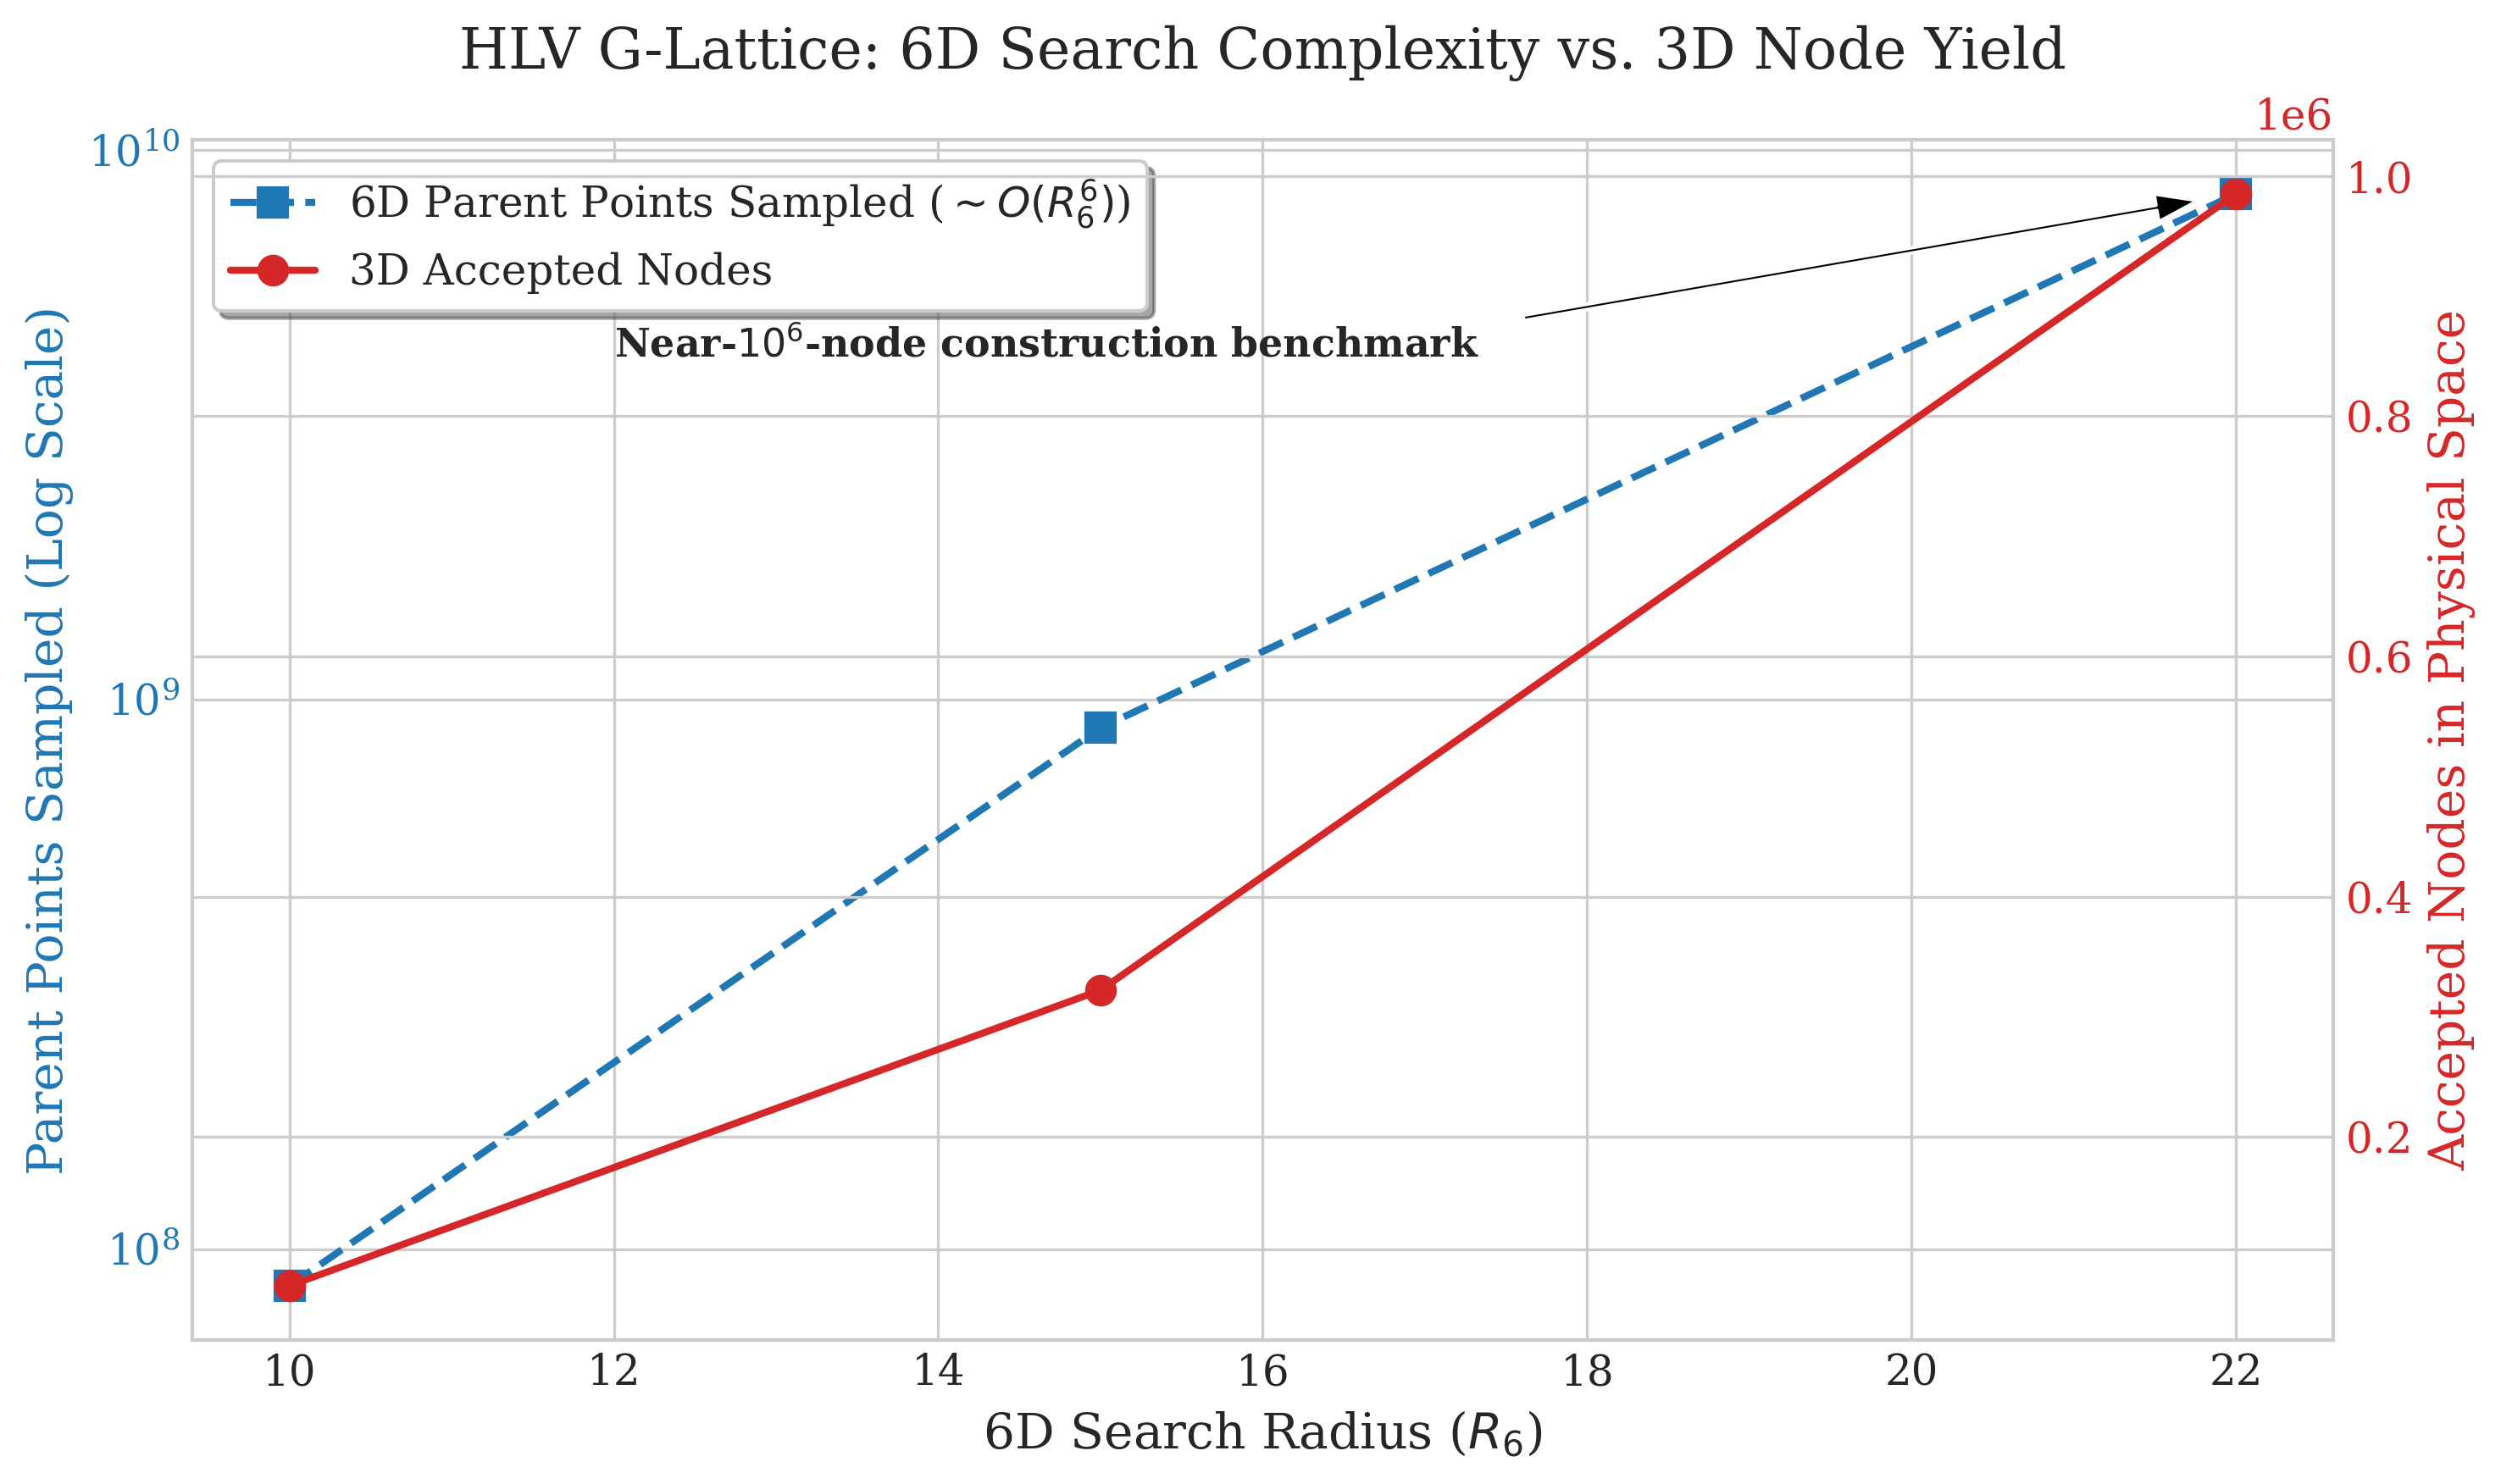

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

# --- PATH-PROOF SETUP ---
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
FIG_DIR = os.path.join(REPO_ROOT, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# Set scientific, reviewer-safe styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'legend.fontsize': 12,
    'font.family': 'serif' # Classic paper aesthetic
})

# 1. The Benchmark Data from our runs
R6_radii = np.array([10, 15, 22])
parent_points_sampled = np.array([85766121, 887503681, 8303765625]) # 6D Space
accepted_nodes = np.array([76027, 322073, 985083])                  # 3D Space

# 2. Setup a Dual-Axis Figure
fig, ax1 = plt.subplots(figsize=(10, 6), dpi=300)

# 3. Plot the 6D Parent Points on a Log Scale
color1 = '#1f77b4'
line1, = ax1.plot(R6_radii, parent_points_sampled, marker='s', markersize=8, 
                  linestyle='--', color=color1, linewidth=2, 
                  label=r'6D Parent Points Sampled ($\sim O(R_6^6)$)')
ax1.set_xlabel(r'6D Search Radius ($R_6$)')
ax1.set_ylabel('Parent Points Sampled (Log Scale)', color=color1)
ax1.set_yscale('log')
ax1.tick_params(axis='y', labelcolor=color1)

# 4. Create a second y-axis for the actual 3D G-Lattice yield
ax2 = ax1.twinx()  
color2 = '#d62728'
line2, = ax2.plot(R6_radii, accepted_nodes, marker='o', markersize=8, 
                  linestyle='-', color=color2, linewidth=2, 
                  label='3D Accepted Nodes')
ax2.set_ylabel('Accepted Nodes in Physical Space', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# 5. Annotate the benchmark
ax2.annotate(r'Near-$10^6$-node construction benchmark', 
             xy=(22, 985083), xytext=(12, 850000),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=11, fontweight='bold')

# 6. Formatting and Legends
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', frameon=True, shadow=True)

plt.title('HLV G-Lattice: 6D Search Complexity vs. 3D Node Yield', pad=20)
plt.tight_layout()

# 7. Save for the Paper (Using Path-Proof Logic)
pdf_path = os.path.join(FIG_DIR, 'HLV_Complexity_Scaling.pdf')
png_path = os.path.join(FIG_DIR, 'HLV_Complexity_Scaling.png')

plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
plt.savefig(png_path, format='png', dpi=300, bbox_inches='tight')

print(f"✅ Benchmark plots saved to:\n - {pdf_path}\n - {png_path}")

plt.show()